In [3]:
import os
import pandas as pd
import numpy as np
import tarfile
from io import StringIO
from functools import reduce
import datetime
import pvlib
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, os.path.join('pv-power-modelling-tools'))
from helpers import filters
from helpers import preprocessing
from helpers import irradiance_transpositions
from helpers import irradiance_decompositions
from helpers import reflection_estimator
from helpers import solar_irradiance_estimator
from helpers import panel_temperature_estimator
from helpers import file_data_processing
import config

# Data pre-processing and initial filtering

## FMI SYSTEMS

In [ ]:
DATA_PATH_FMI = ''

### HELSINKI

In [ ]:
# Read data
data = pd.read_csv(os.path.join(DATA_PATH_FMI, 'FMI_Helsinki_PV.csv'), parse_dates=['utctime'], skiprows=67, delimiter=';')
data = data.rename(columns=config.col_name_dict_helsinki)

data = data[['utctime', 'power', 'pv_inv_out', 'T', 'poa', 'dhi', 'dni', 'ghi', 'module_temp_1', 'module_temp_2', 'snow', 'wind', 'dataQC', 'snow_ground']]

config.set_params_helsinki("", "-")
data = file_data_processing.get_file_data(data)

# Drop the beginning of dataset where POA or power are NaN
data_nonans = data.dropna(subset=['poa_rc', 'power'])
data = data[data.index >= data_nonans.index[0]]

C:\Users\plkart\AppData\Local\Temp\ipykernel_15732\1378568699.py:2: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(DATA_PATH, 'FMI_Helsinki_PV.csv'), parse_dates=['utctime'], skiprows=67, delimiter=';')


Index(['utctime', 'power', 'pv_inv_out', 'T', 'poa', 'dhi', 'dni', 'ghi',
       'module_temp_1', 'module_temp_2', 'snow', 'wind', 'dataQC',
       'snow_ground'],
      dtype='object')
No albedo value in columns. Adding it...
albedo in irradiance transposition: [0.151 0.7  ]
Correcting the measured DNI values...
No projected irradiance components in columns. Calculating them...
albedo in df, using it to calculate ground reflected component
No reflection corrected components in columns. Calculating them...
No poa_comp_rc in columns. Calculating it...
Using Varjopuro coefs
No cell_temp in columns. Calculating it...
Two module_temp values in columns. Averaging them...
filter dict {'iec': {}, 'threshold': {'name': 'power', 'lower': 0, 'upper': 20000}, 'daytime': {}, 'qc': {}, 'snow': {}}
iec in filter_dict
threshold in filter_dict
daytime in filter_dict
qc in filter_dict
snow in filter_dict
Keeping only necessary columns...
                              count         mean          std    

In [ ]:
data.to_csv(os.path.join('Datasets', 'helsinki_prefiltered_filled_missing_data_cell_T_rc_UTC00.csv'), index=False)

### KUOPIO

In [ ]:
# Read data
data = pd.read_csv(os.path.join(DATA_PATH_FMI, 'FMI_Kuopio_PV.csv'), parse_dates=['utctime'], skiprows=67, delimiter=';')
data = data.rename(columns=config.col_name_dict_kuopio)
data = data[['utctime', 'power', 'pv_inv_out', 'T', 'poa', 'dhi', 'ghi', 'module_temp_1', 'module_temp_2', 'snow', 'wind', 'dataQC', 'snow_ground']]

config.set_params_kuopio("", "-")
data = file_data_processing.get_file_data(data)

# Drop the beginning of dataset where POA or power are NaN
data_nonans = data.dropna(subset=['poa_rc', 'power'])
data = data[data.index >= data_nonans.index[0]]

C:\Users\plkart\AppData\Local\Temp\ipykernel_15732\3915960572.py:2: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(DATA_PATH, 'FMI_Kuopio_PV.csv'), parse_dates=['utctime'], skiprows=67, delimiter=';')


Index(['utctime', 'power', 'pv_inv_out', 'T', 'poa', 'dhi', 'ghi',
       'module_temp_1', 'module_temp_2', 'snow', 'wind', 'dataQC',
       'snow_ground'],
      dtype='object')
No albedo value in columns. Adding it...
albedo in irradiance transposition: [0.151 0.7  ]
DNI or DHI not in columns. Decomposing them from GHI...
No projected irradiance components in columns. Calculating them...
albedo in df, using it to calculate ground reflected component
No reflection corrected components in columns. Calculating them...
No poa_comp_rc in columns. Calculating it...
Using Varjopuro coefs
No cell_temp in columns. Calculating it...
Two module_temp values in columns. Averaging them...
filter dict {'iec': {}, 'threshold': {'name': 'power', 'lower': 0, 'upper': 20000}, 'daytime': {}, 'qc': {}, 'snow': {}}
iec in filter_dict
threshold in filter_dict
daytime in filter_dict
qc in filter_dict
snow in filter_dict
Keeping only necessary columns...
                             count         mean       

In [ ]:
data_before_2022 = data[data.index.year<=2021]
data_before_2022.to_csv(os.path.join('Datasets', 'kuopio_prefiltered_filled_missing_data_cell_T_rc_before_2022_UTC00.csv'), index=False)

### SODANKYLÄ 20

In [ ]:
# Read data
data = pd.read_csv(os.path.join(DATA_PATH_FMI, 'FMI_Sodankyla_20deg_PV.csv'), parse_dates=['utctime'], skiprows=93, delimiter=';')
data = data.rename(columns=config.col_name_dict_sodankyla_20)

config.set_params_sodankyla_20("", "-")
data = file_data_processing.get_file_data(data)

# Drop the beginning of dataset where POA or power are NaN
data_nonans = data.dropna(subset=['poa_comp_rc', 'power'])
data = data[data.index >= data_nonans.index[0]]

C:\Users\plkart\AppData\Local\Temp\ipykernel_15732\3334327249.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(DATA_PATH, 'FMI_Sodankyla_20deg_PV.csv'), parse_dates=['utctime'], skiprows=93, delimiter=';')


Index(['utctime', 'id', 'stationname', 'ghi', 'dhi', 'dni', 'GLOBA_PT1M_AVG',
       't_roof', 'module_temp', 'pressure', 'T', 'relative_humid',
       'cloud_coverage', 'wind', 'wind_dir', 'precipitation', 'snow_ground',
       'pv_inv_out', 'snow', 'dataQC', 'Remarks', 'vis_SnoP_val',
       'viss_instant', 'viss_day', 'Count[no]', 'Status[code]', 'DC_V[V]',
       'DC_A[A]', 'power', 'AC_V[V]', 'AC_A[A]', 'AC_P[W]', 'Temp[C]',
       'Energy[Wh]'],
      dtype='object')
No albedo value in columns. Adding it...
albedo in irradiance transposition: [0.7   0.151]
Correcting the measured DNI values...
No projected irradiance components in columns. Calculating them...
albedo in df, using it to calculate ground reflected component
No reflection corrected components in columns. Calculating them...
No poa_comp_rc in columns. Calculating it...
Using Varjopuro coefs
No cell_temp in columns. Calculating it...
Module temperature already in data!
filter dict {'iec': {}, 'threshold': {'name': 'pow

In [ ]:
data.to_csv(os.path.join('Datasets', 'sodankyla20_prefiltered_filled_missing_data_cell_T_rc_UTC00.csv'), index=False)

### Sodankylä 90

In [ ]:
# Read data
data = pd.read_csv(os.path.join(DATA_PATH_FMI, 'FMI_Sodankyla_90deg_PV.csv'), parse_dates=['utctime'], skiprows=93, delimiter=';')
data = data.rename(columns=config.col_name_dict_sodankyla_90)
data = data[['utctime', 'power', 'pv_inv_out', 'T', 'poa', 'dhi', 'dni', 'ghi', 'module_temp', 'snow', 'wind', 'dataQC', 'snow_ground']]


config.set_params_sodankyla_90("", "-")
data = file_data_processing.get_file_data(data)

# Drop the beginning of dataset where POA or power are NaN
data_nonans = data.dropna(subset=['poa_rc', 'power'])
data = data[data.index >= data_nonans.index[0]]

C:\Users\plkart\AppData\Local\Temp\ipykernel_15732\2184940756.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(DATA_PATH, 'FMI_Sodankyla_90deg_PV.csv'), parse_dates=['utctime'], skiprows=93, delimiter=';')


Index(['utctime', 'power', 'pv_inv_out', 'T', 'poa', 'dhi', 'dni', 'ghi',
       'module_temp', 'snow', 'wind', 'dataQC', 'snow_ground'],
      dtype='object')
No albedo value in columns. Adding it...
albedo in irradiance transposition: [0.7   0.151]
Correcting the measured DNI values...
No projected irradiance components in columns. Calculating them...
albedo in df, using it to calculate ground reflected component
No reflection corrected components in columns. Calculating them...
No poa_comp_rc in columns. Calculating it...
Using Varjopuro coefs
No cell_temp in columns. Calculating it...
Module temperature already in data!
filter dict {'iec': {}, 'threshold': {'name': 'power', 'lower': 0, 'upper': 20000}, 'daytime': {}, 'qc': {}, 'snow': {}}
iec in filter_dict
threshold in filter_dict
daytime in filter_dict
qc in filter_dict
snow in filter_dict
Keeping only necessary columns...
                             count        mean         std        min  \
ghi                       708608.0 

In [ ]:
data.to_csv(os.path.join('Datasets', 'sodankyla90_prefiltered_filled_missing_data_cell_T_rc_UTC00.csv'), index=False)

## TUAS SYSTEM

In [ ]:
DATA_PATH_TUAS = ''

### KTK SOUTH
KTK_South_PV_weather_snow_non_cleaned.csv is obtained using merge_weather_and_pv_data function, where
- Etela_fx_DST_17_23.csv is obtained from NERC data portal (Dataset: NERC South Facing Setup, https://nerc.turkuamk.fi/data-portal/) by removing the daylight saving time (timezone UTC+02)
- Weather.csv is obtained from NERC data portal (Datset: NERC East-West Bifacial test setup, https://nerc.turkuamk.fi/data-portal/)
- Turku Artukainen_ 1.1.2018 - 31.12.2020_snow_depth_raw.csv is obtained from FMI's website: https://www.ilmatieteenlaitos.fi/havaintojen-lataus

In [ ]:
data = pd.read_csv(os.path.join(DATA_PATH_TUAS, 'KTK_South_PV_weather_snow_non_cleaned.csv'), delimiter=';', parse_dates=['utctime'], low_memory=False)  # This data is already in UTC+00

# Get the DC power
data['power'] = data.Idc_MPP1 * data.Vdc_MPP1  # MPP2 produces only 0
data['ac_power'] = data.Iac_1 * data.Vac_1 + data.Iac_2 * data.Vac_2 + data.Iac_3 * data.Vac_3

data['GHI'] = np.where(
    (data.irradiance1 - data.irradiance2).abs() < 5,   # condition: difference less than 5
    (data.irradiance1 + data.irradiance2) / 2,         # otherwise NaN 
    np.nan                                            
)

# Drop unnecessary columns
data = data[['utctime', 'power', 'ac_power', 'windSpeed', 'TEMP', 'GHI', 'snow_ground']]

In [27]:
data

,utctime,power,ac_power,windSpeed,TEMP,GHI,snow_ground
0,2017-08-31 07:30:00,0.000,0.000,NaN,NaN,NaN,NaN
1,2017-08-31 07:35:00,184.176,142.418,NaN,NaN,NaN,NaN
2,2017-08-31 07:40:00,189.582,153.479,NaN,NaN,NaN,NaN
3,2017-08-31 07:45:00,220.352,182.441,NaN,NaN,NaN,NaN
4,2017-08-31 07:50:00,210.294,175.898,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2683196,2023-12-31 21:35:00,0.000,0.000,NaN,NaN,NaN,NaN
2683197,2023-12-31 21:40:00,0.000,0.000,NaN,NaN,NaN,NaN
2683198,2023-12-31 21:45:00,0.000,0.000,NaN,NaN,NaN,NaN
2683199,2023-12-31 21:50:00,0.000,0.000,NaN,NaN,NaN,NaN


In [ ]:
data = data.rename(columns={'GHI':'ghi'})
# Remove points after 2nd July 2021, since then GHI remain 0, since the pyranometers were moved
data = data[data.utctime < datetime.datetime(year=2020, month=9, day=18)]
data = data.rename(columns={'ac_power':'pv_inv_out'})

config.set_params_turku("", "-")

data = file_data_processing.get_file_data(data)

# Drop the beginning of dataset where POA or power are NaN
data_nonans = data.dropna(subset=['poa_comp_rc', 'power'])
data = data[data.index >= data_nonans.index[0]]


Index(['utctime', 'power', 'pv_inv_out', 'wind', 'T', 'ghi', 'snow_ground'], dtype='object')
No albedo value in columns. Adding it...
albedo in irradiance transposition: [0.151 0.7  ]
DNI or DHI not in columns. Decomposing them from GHI...
No projected irradiance components in columns. Calculating them...
albedo in df, using it to calculate ground reflected component
No reflection corrected components in columns. Calculating them...
No poa_comp_rc in columns. Calculating it...
Using Varjopuro coefs
No cell_temp in columns. Calculating it...
No module_temp in columns. Calculating it...
filter dict {'iec': {}, 'threshold': {'name': ['power', 'poa_comp'], 'lower': [0, 100], 'upper': [100, 2000], 'negate': True}, 'daytime': {}, 'qc': {}, 'snow': {}}
iec in filter_dict
threshold in filter_dict
daytime in filter_dict
qc in filter_dict
snow in filter_dict
Keeping only necessary columns...
                             count         mean          std        min  \
ghi                       1172

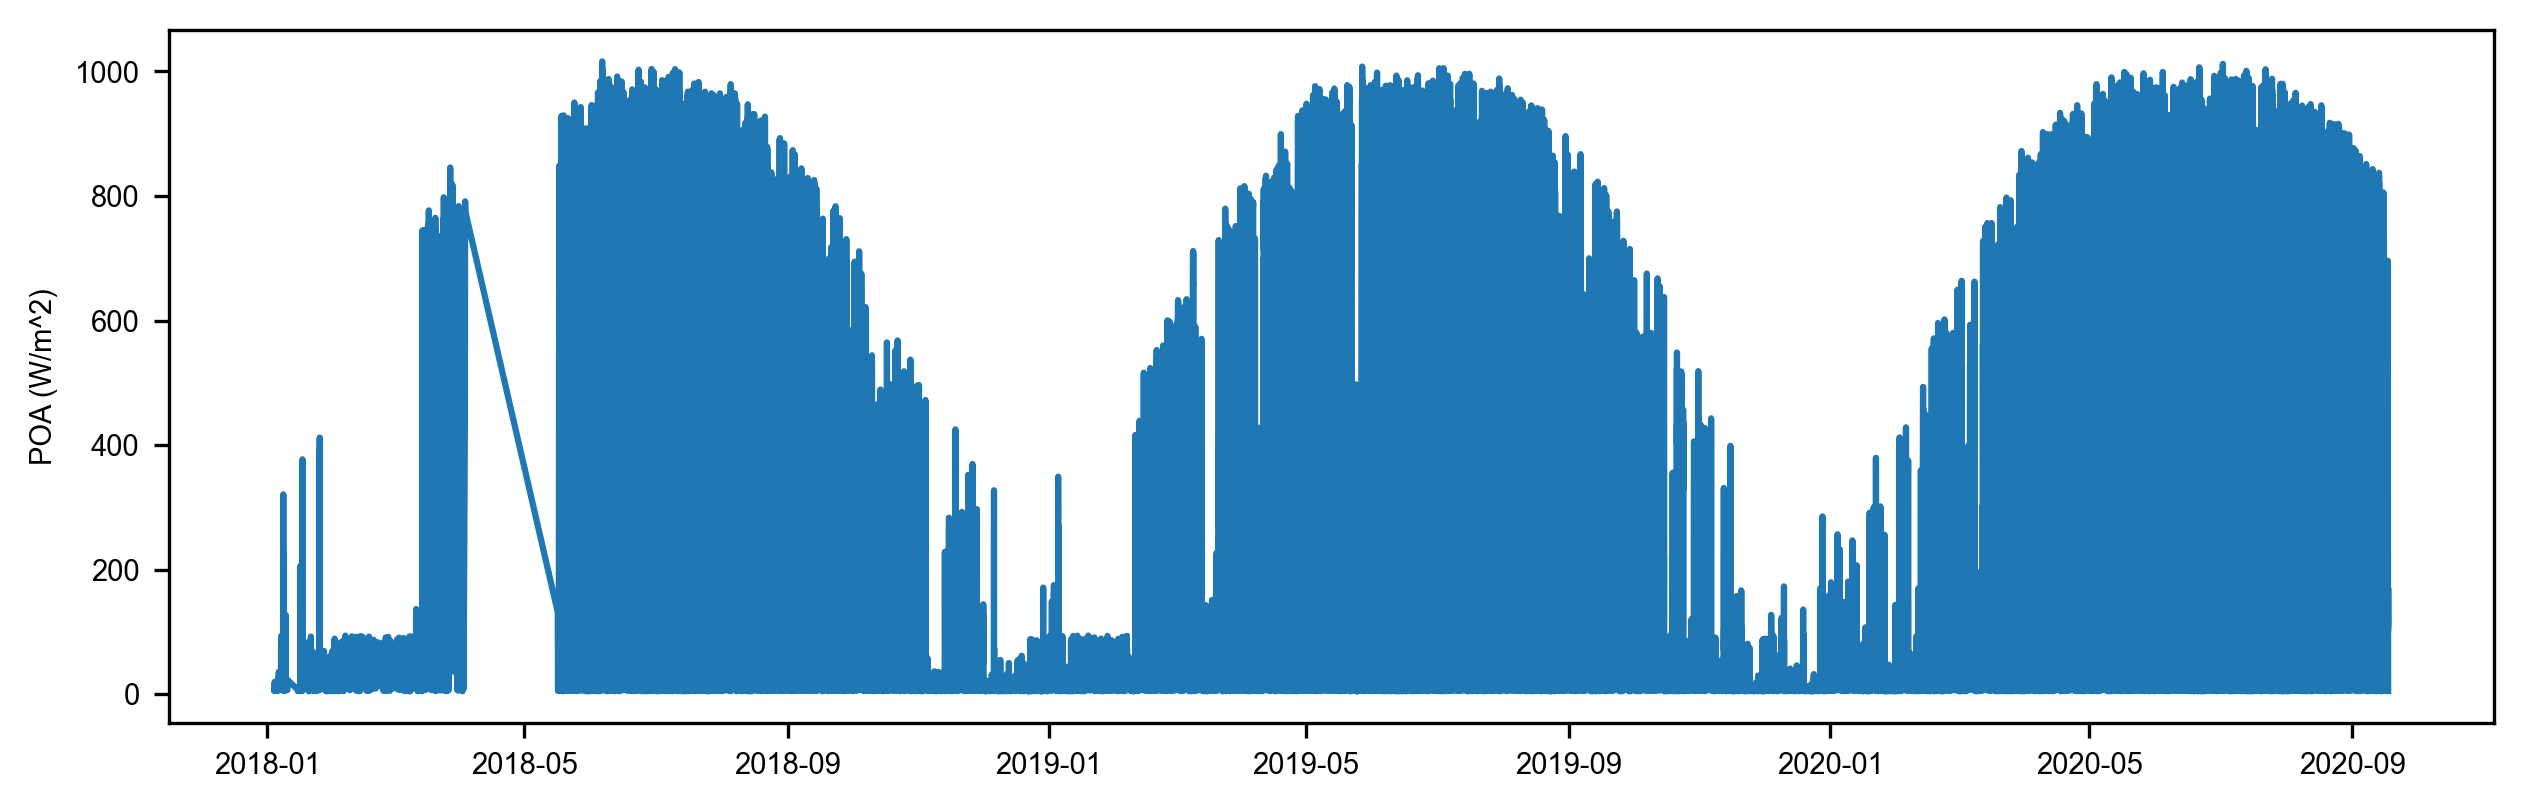

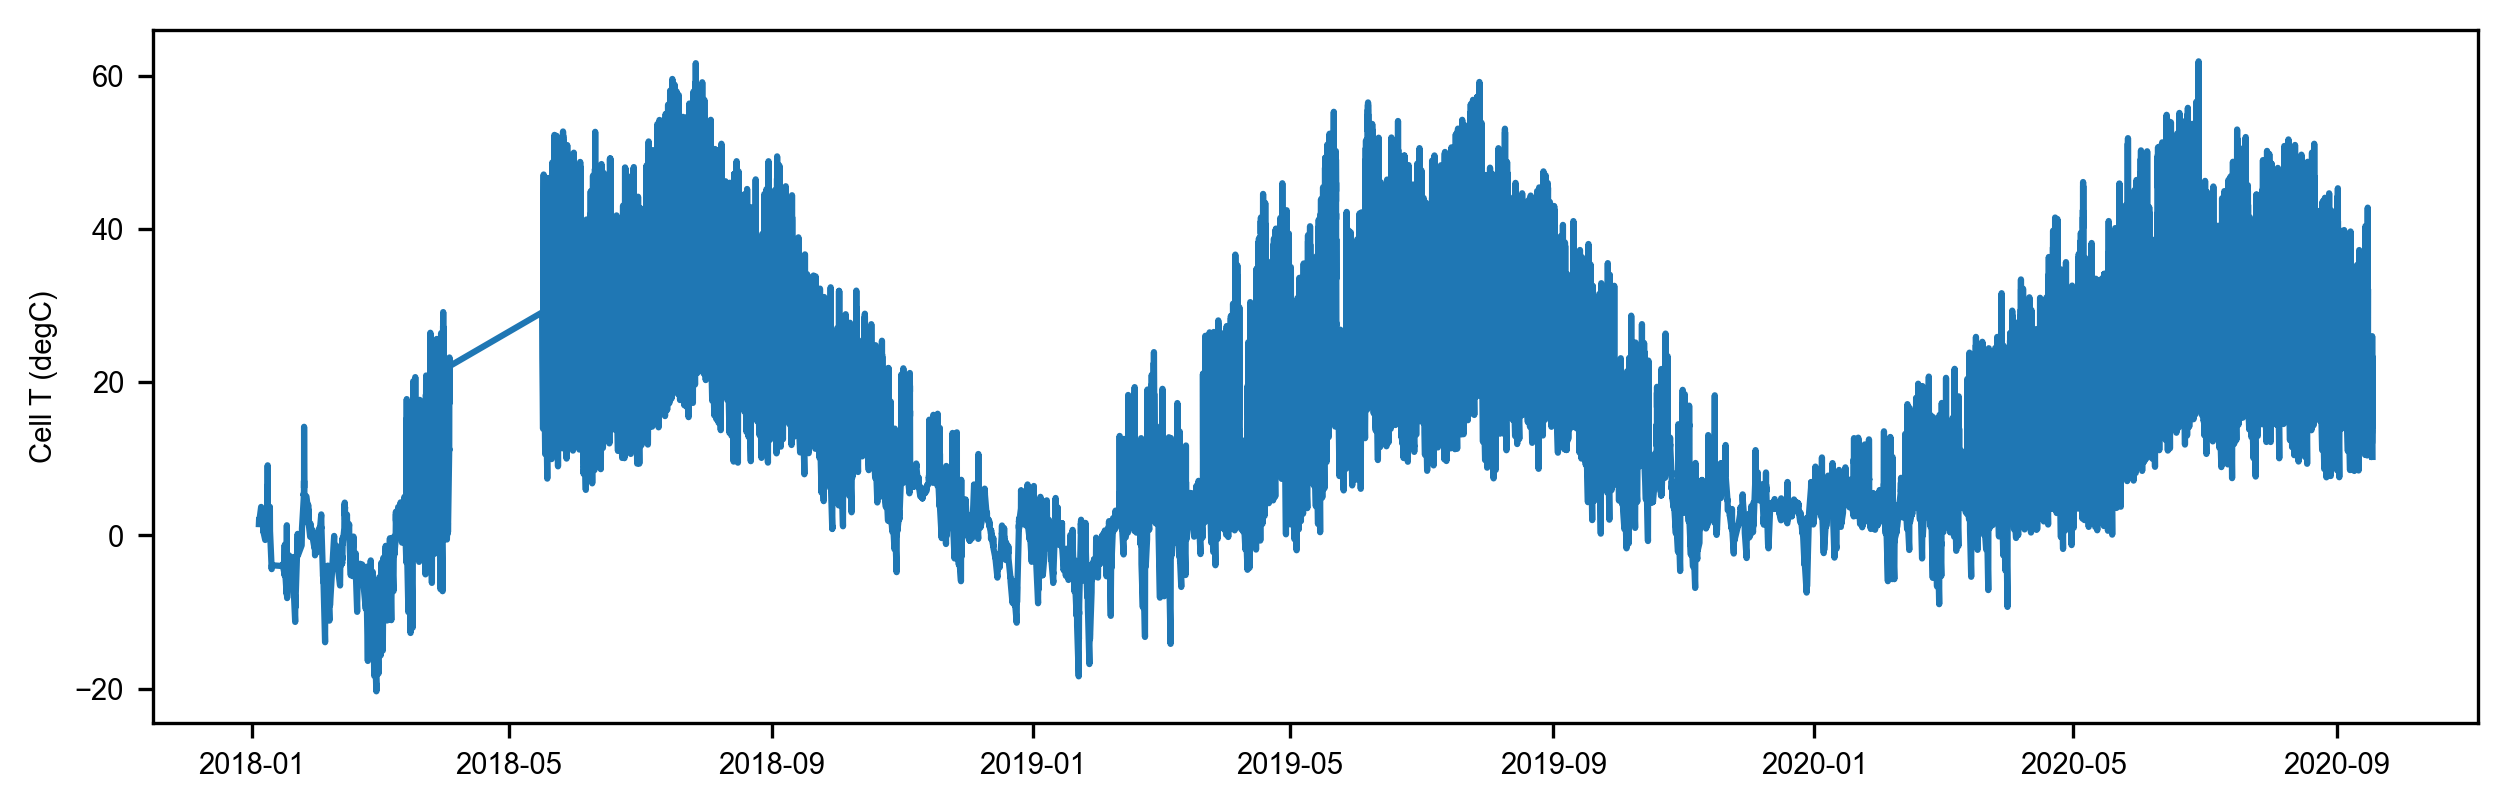

In [29]:
plt.figure(figsize=(10,3))
plt.plot(data.index, data.poa_comp_rc)
plt.ylabel('POA (W/m^2)')
plt.show()
plt.figure(figsize=(10,3))
plt.plot(data.index, data.cell_temp)
plt.ylabel('Cell T (degC)')
plt.show()

In [ ]:
data.to_csv(os.path.join('Datasets', 'turku_prefiltered_south_cell_T_rc_UTC00.csv'), index=False)

## IEA PVPS Task 13-ST2.5: PLR Determination Benchmark Study EDF Dataset
Rath K, French RH, Curran A, Research S, Khalilnejad A, Lindig S, et al.. EDF. Case Western Reserve University 2020. https://osf.io/dy376/overview


In [ ]:
PATH = ''
data = pd.read_csv(os.path.join(PATH, 'DPP_Rennes_HC5AnsELM_DEGx_Task13.csv'), delimiter=';')
data = data.rename(columns={'assemblageChampPVetOnduleur.pVField.Gplan':'poa', 
                            'assemblageChampPVetOnduleur.T_ext.T':'T',
                            'assemblageChampPVetOnduleur.Vit[1]':'wind',
                            'assemblageChampPVetOnduleur.P_AC':'p_inv_in',
                            'assemblageChampPVetOnduleur.P_DC':'power'})

data

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\plkart\AppData\Local\Temp\ipykernel_9156\3085987350.py:1: SyntaxWarning: invalid escape sequence '\D'
  PATH = 'Z:\Data\Data_PVPS_Task13'


,Time,poa,T,wind,p_inv_in,power
0,0,0.0,281.375056,1,0.0,0.0
1,900,0.0,281.339068,1,0.0,0.0
2,1800,0.0,281.303080,1,0.0,0.0
3,2700,0.0,281.267092,1,0.0,0.0
4,3600,0.0,281.235410,1,0.0,0.0
...,...,...,...,...,...,...
175196,157676400,0.0,266.415331,1,0.0,0.0
175197,157677300,0.0,266.813456,1,0.0,0.0
175198,157678200,0.0,267.421374,1,0.0,0.0
175199,157679100,0.0,268.029291,1,0.0,0.0


In [55]:
#start_date = pd.Timestamp('2016-01-01')
data['time'] = pd.to_datetime(data.Time, unit='s') + datetime.timedelta(days=46*365+11)
data['T'] = data['T'] - 273.15
data

,Time,poa,T,wind,p_inv_in,power,time
0,0,0.0,8.225056,1,0.0,0.0,2016-01-01 00:00:00
1,900,0.0,8.189068,1,0.0,0.0,2016-01-01 00:15:00
2,1800,0.0,8.153080,1,0.0,0.0,2016-01-01 00:30:00
3,2700,0.0,8.117092,1,0.0,0.0,2016-01-01 00:45:00
4,3600,0.0,8.085410,1,0.0,0.0,2016-01-01 01:00:00
...,...,...,...,...,...,...,...
175196,157676400,0.0,-6.734669,1,0.0,0.0,2020-12-29 23:00:00
175197,157677300,0.0,-6.336544,1,0.0,0.0,2020-12-29 23:15:00
175198,157678200,0.0,-5.728626,1,0.0,0.0,2020-12-29 23:30:00
175199,157679100,0.0,-5.120708,1,0.0,0.0,2020-12-29 23:45:00


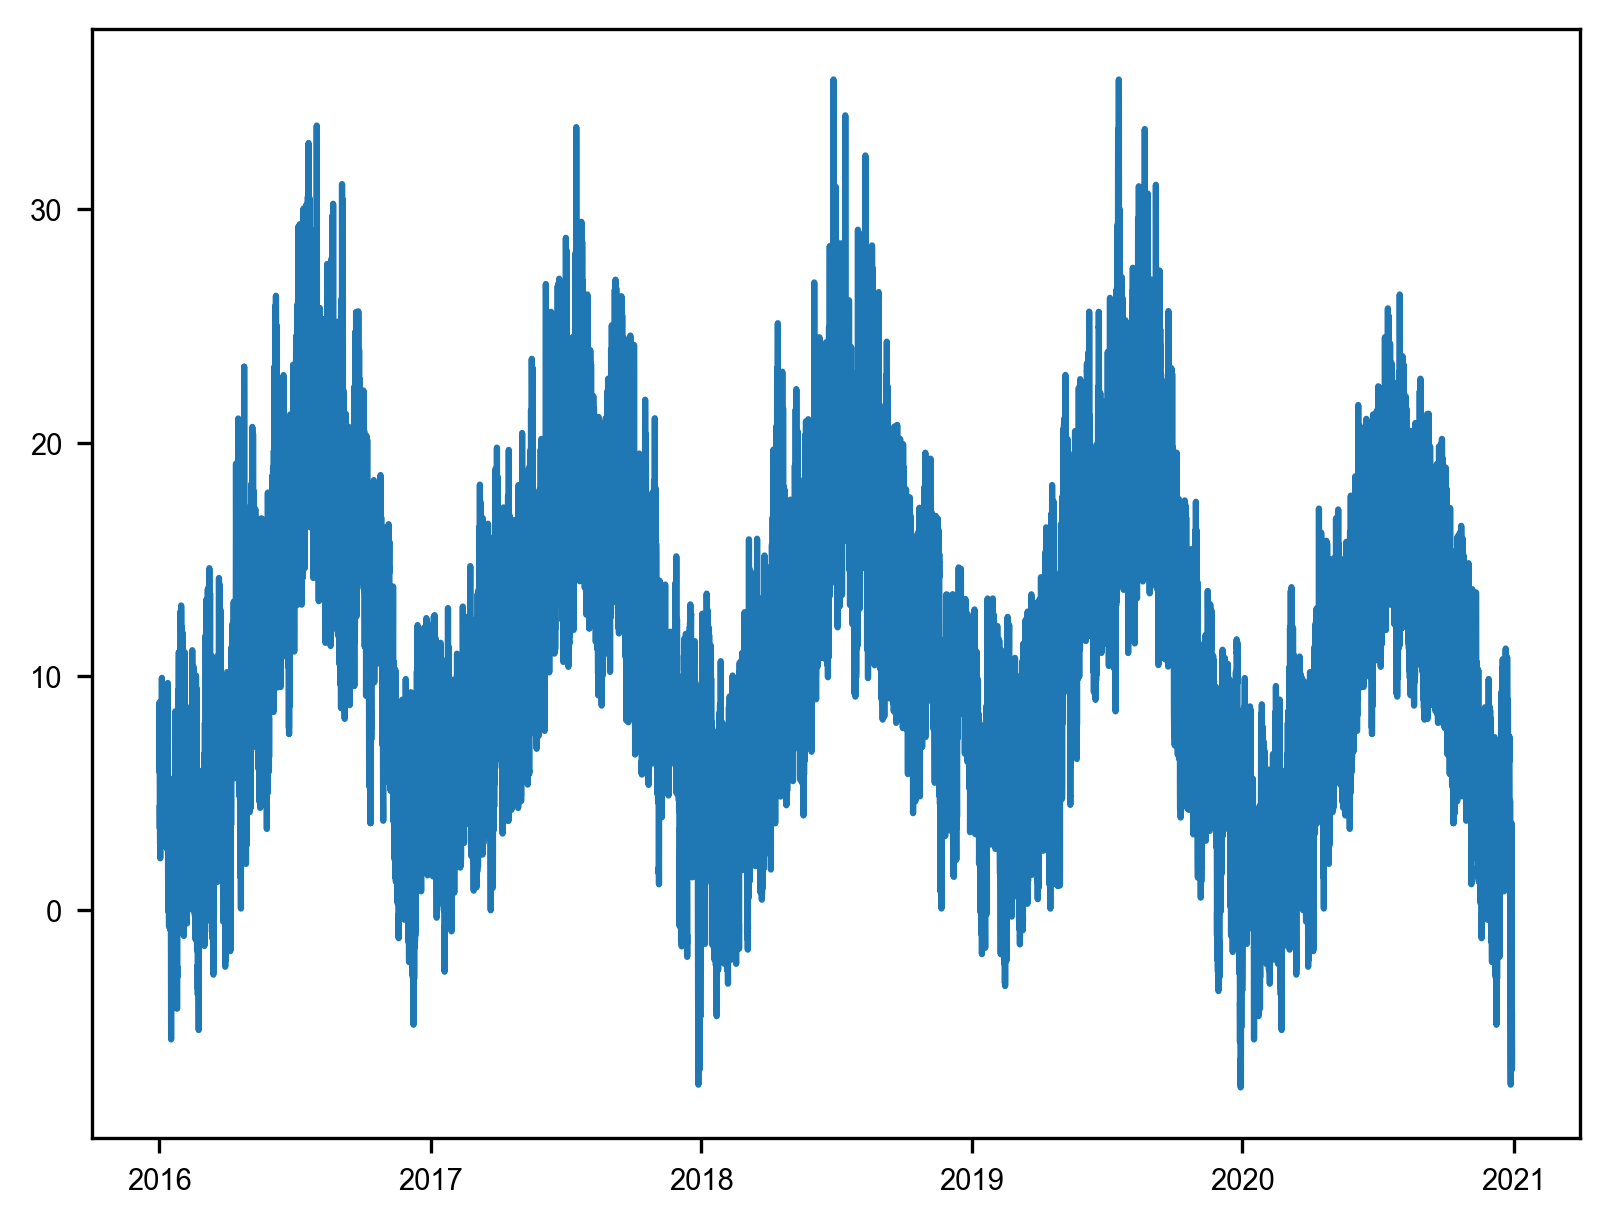

In [57]:
plt.plot(data.time, data['T'])
plt.show()

In [58]:

# Estimate panel temperature based on wind speed, air temperature and absorbed radiation if it's not measured
if "module_temp" not in data.columns:
    if {"module_temp_1", "module_temp_2"}.issubset(data.columns):
        print("Two module_temp values in columns. Averaging them...")
        data["module_temp"] = preprocessing.merge_measurements(data, ["module_temp_1", "module_temp_2"], 10)
        data.drop(columns=["module_temp_1", "module_temp_2"], inplace=True)
    else:
        print("No module_temp in columns. Calculating it...")
        data = panel_temperature_estimator.add_estimated_panel_temperature(data, irradiance_col_name="poa",
                                                                                    estimated_variable='module_temp')
else:
    print("Module temperature already in data!")
    
# Estimate cell temperature based on module temperature, and absorbed radiation if it's not measured
if "cell_temp" not in data.columns:
    print("No cell_temp in columns. Calculating it...")
    data = panel_temperature_estimator.add_estimated_cell_temperature(data, 1, poa_name="poa")
else:
    print("Cell temperature already in data!")


No module_temp in columns. Calculating it...
No cell_temp in columns. Calculating it...


In [59]:
data

,Time,poa,T,wind,p_inv_in,power,time,module_temp,cell_temp
0,0,0.0,8.225056,1,0.0,0.0,2016-01-01 00:00:00,8.225056,8.225056
1,900,0.0,8.189068,1,0.0,0.0,2016-01-01 00:15:00,8.189068,8.189068
2,1800,0.0,8.153080,1,0.0,0.0,2016-01-01 00:30:00,8.153080,8.153080
3,2700,0.0,8.117092,1,0.0,0.0,2016-01-01 00:45:00,8.117092,8.117092
4,3600,0.0,8.085410,1,0.0,0.0,2016-01-01 01:00:00,8.085410,8.085410
...,...,...,...,...,...,...,...,...,...
175196,157676400,0.0,-6.734669,1,0.0,0.0,2020-12-29 23:00:00,-6.734669,-6.734669
175197,157677300,0.0,-6.336544,1,0.0,0.0,2020-12-29 23:15:00,-6.336544,-6.336544
175198,157678200,0.0,-5.728626,1,0.0,0.0,2020-12-29 23:30:00,-5.728626,-5.728626
175199,157679100,0.0,-5.120708,1,0.0,0.0,2020-12-29 23:45:00,-5.120708,-5.120708


In [ ]:
data.to_csv('Datasets\simulated_1.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\O'
C:\Users\plkart\AppData\Local\Temp\ipykernel_9156\3945337501.py:1: SyntaxWarning: invalid escape sequence '\O'
  data.to_csv('Z:\Ongoing_works\EUPVSEC_25\Datasets\simulated_1.csv', index=False)


In [ ]:
PATH = ''
data = pd.read_csv(os.path.join(PATH, 'DPP_Rennes_HC5AnsELM_DEG0_Task13.csv'), delimiter=';')
data = data.rename(columns={'assemblageChampPVetOnduleur.pVField.Gplan':'poa', 
                            'assemblageChampPVetOnduleur.T_ext.T':'T',
                            'assemblageChampPVetOnduleur.Vit[1]':'wind',
                            'assemblageChampPVetOnduleur.P_AC':'p_inv_in',
                            'assemblageChampPVetOnduleur.P_DC':'power'})

data

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\plkart\AppData\Local\Temp\ipykernel_16196\2533508918.py:1: SyntaxWarning: invalid escape sequence '\D'
  PATH = 'Z:\Data\Data_PVPS_Task13'


,Time,poa,T,wind,p_inv_in,power
0,0,0.0,281.375056,1,0.0,0.0
1,900,0.0,281.339068,1,0.0,0.0
2,1800,0.0,281.303080,1,0.0,0.0
3,2700,0.0,281.267092,1,0.0,0.0
4,3600,0.0,281.235410,1,0.0,0.0
...,...,...,...,...,...,...
175196,157676400,0.0,266.415331,1,0.0,0.0
175197,157677300,0.0,266.813456,1,0.0,0.0
175198,157678200,0.0,267.421374,1,0.0,0.0
175199,157679100,0.0,268.029291,1,0.0,0.0


In [4]:
#start_date = pd.Timestamp('2016-01-01')
data['time'] = pd.to_datetime(data.Time, unit='s') + datetime.timedelta(days=46*365+11)
data['T'] = data['T'] - 273.15
data

,Time,poa,T,wind,p_inv_in,power,time
0,0,0.0,8.225056,1,0.0,0.0,2016-01-01 00:00:00
1,900,0.0,8.189068,1,0.0,0.0,2016-01-01 00:15:00
2,1800,0.0,8.153080,1,0.0,0.0,2016-01-01 00:30:00
3,2700,0.0,8.117092,1,0.0,0.0,2016-01-01 00:45:00
4,3600,0.0,8.085410,1,0.0,0.0,2016-01-01 01:00:00
...,...,...,...,...,...,...,...
175196,157676400,0.0,-6.734669,1,0.0,0.0,2020-12-29 23:00:00
175197,157677300,0.0,-6.336544,1,0.0,0.0,2020-12-29 23:15:00
175198,157678200,0.0,-5.728626,1,0.0,0.0,2020-12-29 23:30:00
175199,157679100,0.0,-5.120708,1,0.0,0.0,2020-12-29 23:45:00


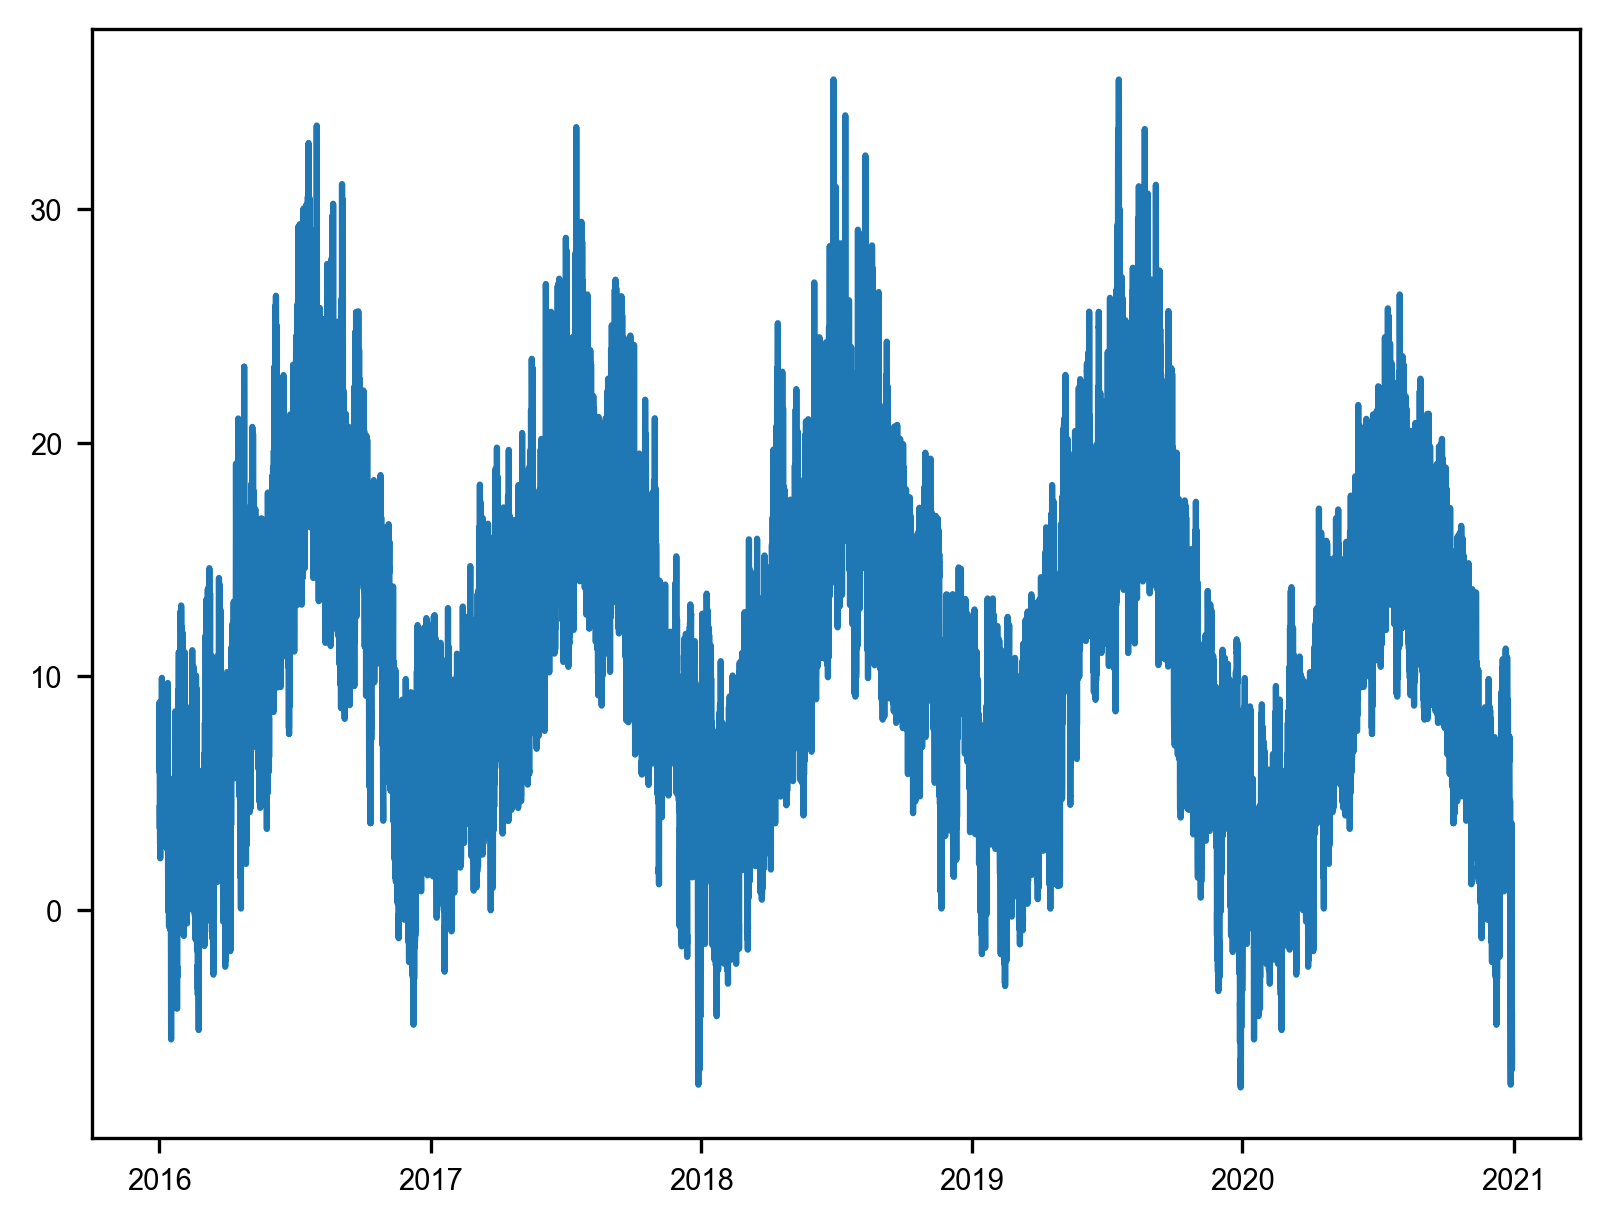

In [5]:
plt.plot(data.time, data['T'])
plt.show()

In [6]:

# Estimate panel temperature based on wind speed, air temperature and absorbed radiation if it's not measured
if "module_temp" not in data.columns:
    if {"module_temp_1", "module_temp_2"}.issubset(data.columns):
        print("Two module_temp values in columns. Averaging them...")
        data["module_temp"] = preprocessing.merge_measurements(data, ["module_temp_1", "module_temp_2"], 10)
        data.drop(columns=["module_temp_1", "module_temp_2"], inplace=True)
    else:
        print("No module_temp in columns. Calculating it...")
        data = panel_temperature_estimator.add_estimated_panel_temperature(data, irradiance_col_name="poa",
                                                                                    estimated_variable='module_temp')
else:
    print("Module temperature already in data!")
    
# Estimate cell temperature based on module temperature, and absorbed radiation if it's not measured
if "cell_temp" not in data.columns:
    print("No cell_temp in columns. Calculating it...")
    data = panel_temperature_estimator.add_estimated_cell_temperature(data, 1, poa_name="poa")
else:
    print("Cell temperature already in data!")


No module_temp in columns. Calculating it...
No cell_temp in columns. Calculating it...


In [7]:
data

,Time,poa,T,wind,p_inv_in,power,time,module_temp,cell_temp
0,0,0.0,8.225056,1,0.0,0.0,2016-01-01 00:00:00,8.225056,8.225056
1,900,0.0,8.189068,1,0.0,0.0,2016-01-01 00:15:00,8.189068,8.189068
2,1800,0.0,8.153080,1,0.0,0.0,2016-01-01 00:30:00,8.153080,8.153080
3,2700,0.0,8.117092,1,0.0,0.0,2016-01-01 00:45:00,8.117092,8.117092
4,3600,0.0,8.085410,1,0.0,0.0,2016-01-01 01:00:00,8.085410,8.085410
...,...,...,...,...,...,...,...,...,...
175196,157676400,0.0,-6.734669,1,0.0,0.0,2020-12-29 23:00:00,-6.734669,-6.734669
175197,157677300,0.0,-6.336544,1,0.0,0.0,2020-12-29 23:15:00,-6.336544,-6.336544
175198,157678200,0.0,-5.728626,1,0.0,0.0,2020-12-29 23:30:00,-5.728626,-5.728626
175199,157679100,0.0,-5.120708,1,0.0,0.0,2020-12-29 23:45:00,-5.120708,-5.120708


In [ ]:
data.to_csv('Datasets\simulated_3.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\O'
C:\Users\plkart\AppData\Local\Temp\ipykernel_16196\427629084.py:1: SyntaxWarning: invalid escape sequence '\O'
  data.to_csv('Z:\Ongoing_works\EUPVSEC_25\Datasets\simulated_3.csv', index=False)


<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\plkart\AppData\Local\Temp\ipykernel_9156\1260801364.py:1: SyntaxWarning: invalid escape sequence '\D'
  PATH = 'Z:\Data\Data_PVPS_Task13'


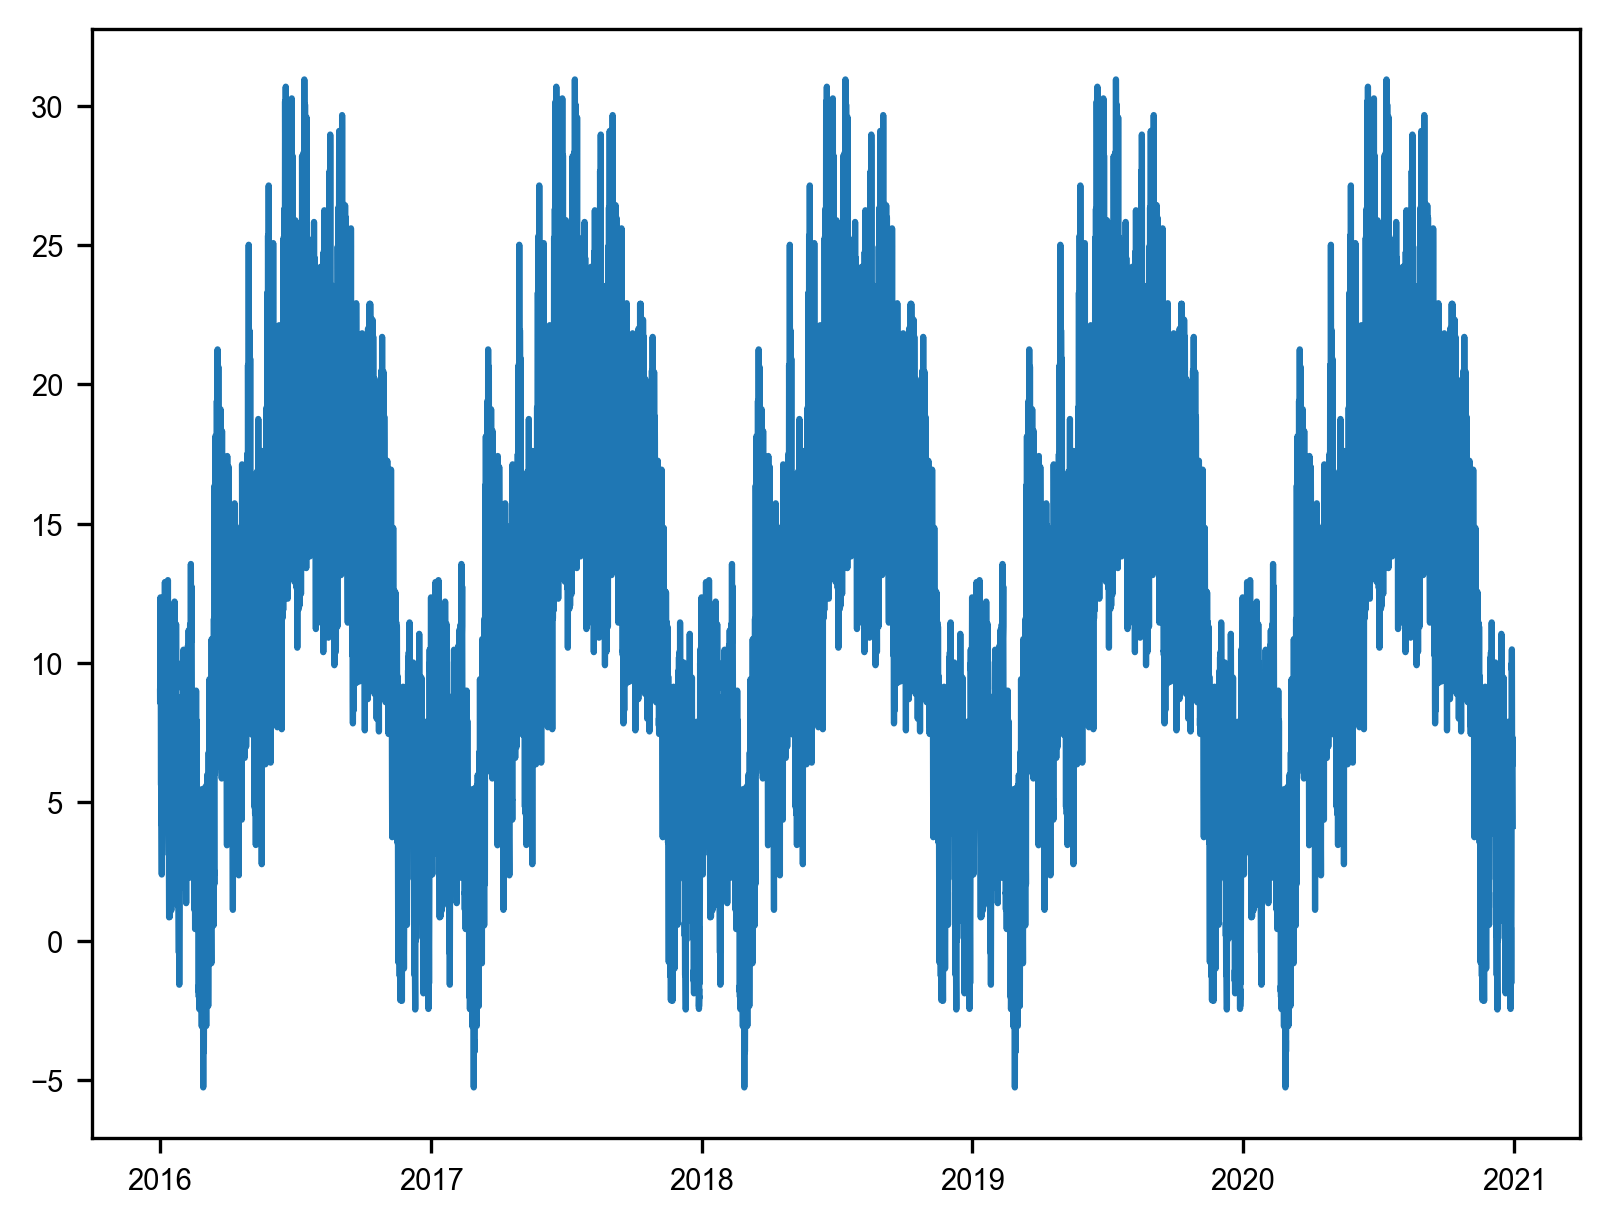

No module_temp in columns. Calculating it...
No cell_temp in columns. Calculating it...


In [ ]:
PATH = ''
data = pd.read_csv(os.path.join(PATH, 'Rennes_SameMeteo_5ans_Degx_Task13.csv'), delimiter=';')
data = data.rename(columns={'assemblageChampPVetOnduleur.pVField.Gplan':'poa', 
                            'assemblageChampPVetOnduleur.T_ext.T':'T',
                            'assemblageChampPVetOnduleur.Vit[1]':'wind',
                            'assemblageChampPVetOnduleur.P_AC':'p_inv_in',
                            'assemblageChampPVetOnduleur.P_DC':'power'})

#start_date = pd.Timestamp('2016-01-01')
data['time'] = pd.to_datetime(data.Time, unit='s') + datetime.timedelta(days=46*365+11)
data['T'] = data['T'] - 273.15
plt.plot(data.time, data['T'])
plt.show()

# Estimate panel temperature based on wind speed, air temperature and absorbed radiation if it's not measured
if "module_temp" not in data.columns:
    if {"module_temp_1", "module_temp_2"}.issubset(data.columns):
        print("Two module_temp values in columns. Averaging them...")
        data["module_temp"] = preprocessing.merge_measurements(data, ["module_temp_1", "module_temp_2"], 10)
        data.drop(columns=["module_temp_1", "module_temp_2"], inplace=True)
    else:
        print("No module_temp in columns. Calculating it...")
        data = panel_temperature_estimator.add_estimated_panel_temperature(data, irradiance_col_name="poa",
                                                                                    estimated_variable='module_temp')
else:
    print("Module temperature already in data!")
    
# Estimate cell temperature based on module temperature, and absorbed radiation if it's not measured
if "cell_temp" not in data.columns:
    print("No cell_temp in columns. Calculating it...")
    data = panel_temperature_estimator.add_estimated_cell_temperature(data, 1, poa_name="poa")
else:
    print("Cell temperature already in data!")

In [ ]:
data.to_csv('Datasets\simulated_2.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\O'
C:\Users\plkart\AppData\Local\Temp\ipykernel_9156\1074811426.py:1: SyntaxWarning: invalid escape sequence '\O'
  data.to_csv('Z:\Ongoing_works\EUPVSEC_25\Datasets\simulated_2.csv', index=False)


<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\plkart\AppData\Local\Temp\ipykernel_16196\686035835.py:1: SyntaxWarning: invalid escape sequence '\D'
  PATH = 'Z:\Data\Data_PVPS_Task13'


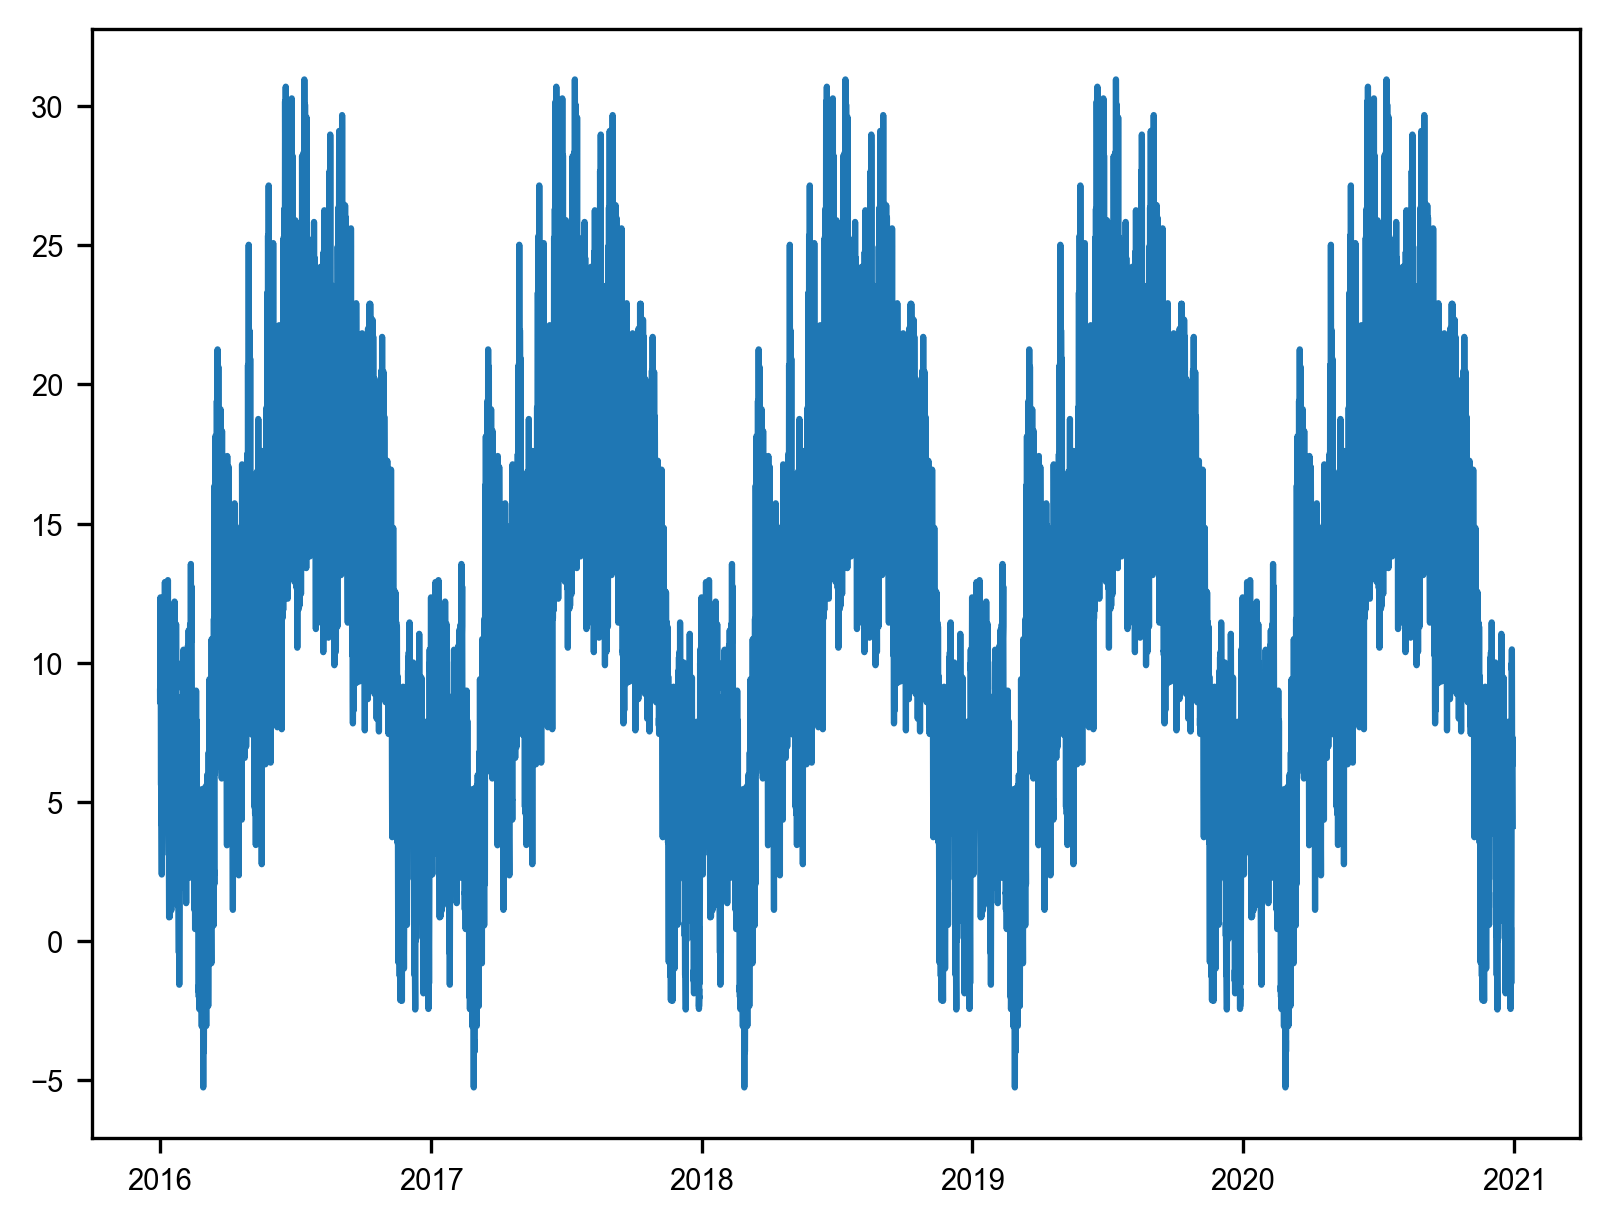

No module_temp in columns. Calculating it...
No cell_temp in columns. Calculating it...


In [ ]:
PATH = ''
data = pd.read_csv(os.path.join(PATH, 'Rennes_SameMeteo_5ans_Deg0_Task13.csv'), delimiter=';')
data = data.rename(columns={'assemblageChampPVetOnduleur.pVField.Gplan':'poa', 
                            'assemblageChampPVetOnduleur.T_ext.T':'T',
                            'assemblageChampPVetOnduleur.Vit[1]':'wind',
                            'assemblageChampPVetOnduleur.P_AC':'p_inv_in',
                            'assemblageChampPVetOnduleur.P_DC':'power'})

#start_date = pd.Timestamp('2016-01-01')
data['time'] = pd.to_datetime(data.Time, unit='s') + datetime.timedelta(days=46*365+11)
data['T'] = data['T'] - 273.15
plt.plot(data.time, data['T'])
plt.show()

# Estimate panel temperature based on wind speed, air temperature and absorbed radiation if it's not measured
if "module_temp" not in data.columns:
    if {"module_temp_1", "module_temp_2"}.issubset(data.columns):
        print("Two module_temp values in columns. Averaging them...")
        data["module_temp"] = preprocessing.merge_measurements(data, ["module_temp_1", "module_temp_2"], 10)
        data.drop(columns=["module_temp_1", "module_temp_2"], inplace=True)
    else:
        print("No module_temp in columns. Calculating it...")
        data = panel_temperature_estimator.add_estimated_panel_temperature(data, irradiance_col_name="poa",
                                                                                    estimated_variable='module_temp')
else:
    print("Module temperature already in data!")
    
# Estimate cell temperature based on module temperature, and absorbed radiation if it's not measured
if "cell_temp" not in data.columns:
    print("No cell_temp in columns. Calculating it...")
    data = panel_temperature_estimator.add_estimated_cell_temperature(data, 1, poa_name="poa")
else:
    print("Cell temperature already in data!")

In [ ]:
data.to_csv('Datasets\simulated_4.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\O'
C:\Users\plkart\AppData\Local\Temp\ipykernel_16196\4001777402.py:1: SyntaxWarning: invalid escape sequence '\O'
  data.to_csv('Z:\Ongoing_works\EUPVSEC_25\Datasets\simulated_4.csv', index=False)
